# Практическая работа № 3
# "Conditional GAN для генерации изображений собак"

> @Гришина Ксения, 23.Б16-мм

## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 3

> Ваша задача — разработать и обучить модель Conditional GAN для генерации изображений собак различных пород. В отличие от обычной GAN, условная GAN получает дополнительную информацию о классе изображения — в данном случае о породе собаки. Это позволяет управлять генерацией и получать изображения собак заданной породы. Работа выполняется в формате Jupyter Notebook или Google Colab.

> Задачи для выполнения работы:
> 1. Теоретическая справка:
В начале работы необходимо кратко описать: цель практической работы; основные задачи, которые будут решаться; что такое генеративно-состязательные сети; чем Conditional GAN отличается от обычной GAN; роль генератора и дискриминатора; как в модель передаётся информация о породе собаки.
Также необходимо кратко описать инструменты, с которыми вы будете работать: какие библиотеки используете; для чего предназначена каждая библиотека; какие задачи она позволяет решать; какие методы и функции вы используете в данной работе.
> 2. Датасет:
Необходимо загрузить предоставленный датасет с изображениями собак разных пород.
Ссылка на папку с данными: https://drive.google.com/drive/folders/1DFNae2rSmSss0Swg9c0OskCfQlVHtT9_?usp=sharing
> 3. Создание класса генератора:
Необходимо создать класс нейронной сети — генератора. Генератор должен: принимать случайный вектор шума; принимать метку породы; объединять шум и информацию о породе; генерировать изображение собаки заданной породы.
После реализации класса необходимо кратко описать архитектуру генератора: какие слои используются и зачем.
> 4. Создание класса дискриминатора:
Необходимо создать класс нейронной сети — дискриминатора. Дискриминатор должен: принимать изображение; принимать метку породы; учитывать соответствие изображения заданной породе; выдавать вероятность того, что изображение является настоящим. После реализации класса необходимо кратко объяснить, каким образом дискриминатор использует информацию о породе.
> 5. Функция обучения Conditional GAN:
Необходимо создать функцию для обучения модели. Функция обучения должна включать: инициализацию функций потерь; инициализацию оптимизаторов; обучение дискриминатора на настоящих изображениях; обучение дискриминатора на сгенерированных изображениях; обучение генератора; сохранение значений ошибок генератора и дискриминатора; периодический вывод промежуточных результатов генерации.
> 6. Визуализация промежуточных результатов:
Во время обучения необходимо визуализировать изображения, созданные генератором. Требуется: выводить сгенерированные изображения через заданное количество эпох; использовать фиксированный набор пород и шума для отслеживания прогресса; кратко описывать, как меняется качество изображений в процессе обучения.
Необходимо обратить внимание: появляются ли признаки собак; отличаются ли изображения разных пород; становятся ли изображения более чёткими; есть ли повторяющиеся или неудачные результаты.
> 7. Финальная генерация изображений:
После завершения обучения необходимо продемонстрировать финальные результаты. Требуется: сгенерировать изображения для нескольких пород;
показать результаты в виде сетки; подписать, какой породе соответствует каждое изображение; сравнить с реальными изображениями из предоставленного датасета.
> 8.  Анализ результатов:
Необходимо провести краткий анализ качества модели. В анализе нужно рассмотреть: графики потерь генератора и дискриминатора; стабильность обучения; качество полученных изображений; насколько хорошо модель учитывает породу; какие породы генерируются лучше; какие ошибки возникают при генерации.
Также необходимо указать возможные причины проблем, например: малое количество эпох; небольшой размер датасета; сложность изображений; несбалансированность пород; нестабильность обучения GAN.
> 9. Итоговый отчёт:
Необходимо оформить полный отчёт по работе. Отчёт можно сделать в Jupyter Notebook или Google Collab.

> Все работы прикреплять в таблицу в виде комментария. 

> За работу можно получить до **15 баллов** без учета дополнительных.

> Дедлайн работы: 14.05.2026

---




# Ход работы

## 1 Теоретическая справка

- **Цель:** Разработать и обучить модель Conditional GAN (условная генеративно-состязательная сеть) для генерации изображений собак различных пород.

- **Задачи**:
1. Изучить принципы работы Conditional GAN
2. Загрузить подготовленный датасет с изображениями собак разных пород
3. Реализовать архитектуру генератора и дискриминатора
4. Обучить модель
5. Проанализировать качество генерации и визуализировать результаты

- **GAN** - это класс нейронных сетей, состоящий из двух частей:
1. Генератор (Generator) - создает искусственные изображения из случайного шума
2. Дискриминатор (Discriminator) - отличает настоящие изображения от сгенерированных

Они обучаются одновременно, "состязаясь" друг с другом: Генератор старается обмануть дискриминатор, создавая все более реалистичные изображения, а дискриминатор учится лучше отличать настоящие изображения от "подделок"

- **Отличие Conditional GAN от GAN:**
В обычной GAN генератор создает случайные изображения без возможности управления.
В Conditional GAN (cGAN) и генератор, и дискриминатор получают дополнительную информацию
о классе (условии) - в нашем случае о породе собаки. Это позволяет: Генерировать изображения конкретной породы по запросу; дискриминатору проверять не только реалистичность, но и соответствие породе


- **Роль генератора:**
  - Принимает на вход случайный вектор (шум) и метку породы;
  - Преобразует шум в изображение собаки заданной породы;
  - Учится создавать реалистичные изображения, которым удастся обмануть дискриминатор
- **Роль дискриминатора:**
  - Принимает изображение и метку породы;
  - Оценивает, является ли изображение настоящим или сгенерированным;
  - Проверяет соответствие изображения указанной породе;
  - Помогает генератору улучшать качество генерации через обратную связь

- **Как в модель передается информация:**
  - Порода кодируется в виде числовой метки (0, 1, 2, ...)
  - Метка преобразуется в вектор с помощью embedding слоя
  - В генераторе: вектор породы объединяется с шумом
  - В дискриминаторе: вектор породы объединяется с изображением

- !**Используемые иструменты:**
| № | Библиотека | Назначение | Основные методы |
|---|------------|------------|-----------------|
| 1 | PyTorch (torch)| фреймворк глубокого обучения | `.nn`, `.optim` , и др для реализации|
| 2 | torchvision| работа с изображениями | `transforms`, и др |
| 3 | NumPy | Работа с массивами | `clip()`  |
| 4 | Matplotlib | Визуализация | `plot()`, `show()` |
| + | tqdm | Прогресс-бар для обучения | `.write()` |
| + | gdown, tarfil, shutil, glob, os | Для загрузки датасета | весь раздел 2 |




### ∀ Импорты

In [ ]:
# Импорт библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import gdown
import tarfile
import shutil
import glob

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

# Установка seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Используемое устройство: cpu


In [ ]:
# Гиперпараметры
IMAGE_SIZE = 64  # Размер изображения (64x64 пикселя)
BATCH_SIZE = 32  # Размер батча
LATENT_DIM = 100  # Размерность вектора шума (входные данные генератора)
NUM_EPOCHS = 30  # Количество эпох обучения
LEARNING_RATE = 0.001  # Скорость обучения
BETA1 = 0.1  # Параметр для оптимизатора Adam

## 2 Датасет

Загружаем датасет по ссылке

Датасет находится в Google Drive и содержит два tar-архива:
- annotations.tar - аннотации (метаданные)
- images.tar - изображения собак по породам

In [ ]:
# Создаем необходимые папки
os.makedirs('data', exist_ok=True)

# ID папки с данными
folder_id = '1DFNae2rSmSss0Swg9c0OskCfQlVHtT9_'

# Загружаем всю папку
# Используем gdown для загрузки папки целиком
!pip install -q gdown
!gdown --folder https://drive.google.com/drive/folders/{folder_id} -O ./data/temp --remaining-ok

# Ищем tar-архивы в загруженной папке
tar_files = glob.glob('./data/temp/*.tar')
print(f"Найдено архивов: {len(tar_files)}")

for tar_file in tar_files:
    print(f"Распаковка: {tar_file}")
    with tarfile.open(tar_file, 'r') as tar:
        tar.extractall('./data/temp')
    print(f"- Распаковано: {tar_file}")

# После распаковки images.tar должна появиться папка Images с подпапками пород
# Перемещаем ее в нужное место
if os.path.exists('./data/temp/Images'):
    if os.path.exists('./data/dogs'):
        shutil.rmtree('./data/dogs')
    shutil.move('./data/temp/Images', './data/dogs')
    print("- Папка Images перемещена в ./data/dogs")

# Очищаем временные файлы
for tar_file in tar_files:
    if os.path.exists(tar_file):
        os.remove(tar_file)
        print(f"- Удален: {tar_file}")

Retrieving folder contents
Processing file 1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd Копия annotation.tar
Processing file 1mftPpFflz7vQ1h5756OWWjIempb1D85V Копия images.tar
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd
From (redirected): https://drive.google.com/uc?id=1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd&confirm=t&uuid=69b3b62e-cfe9-4221-b082-bbf7953747d7
To: /content/data/temp/Копия annotation.tar
100% 21.9M/21.9M [00:00<00:00, 44.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1mftPpFflz7vQ1h5756OWWjIempb1D85V
From (redirected): https://drive.google.com/uc?id=1mftPpFflz7vQ1h5756OWWjIempb1D85V&confirm=t&uuid=baf57397-3fc8-4996-9507-fa3228f14cdd
To: /content/data/temp/Копия images.tar
100% 794M/794M [00:11<00:00, 67.2MB/s]
Download completed
Найдено архивов: 2
Распаковка: ./data/temp/Копия annotation.tar


/tmp/ipykernel_3022/399615286.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('./data/temp')


- Распаковано: ./data/temp/Копия annotation.tar
Распаковка: ./data/temp/Копия images.tar
- Распаковано: ./data/temp/Копия images.tar
- Папка Images перемещена в ./data/dogs
- Удален: ./data/temp/Копия annotation.tar
- Удален: ./data/temp/Копия images.tar


In [ ]:
# Проверяем структуру датасета
if os.path.exists('./data/dogs'):
    breeds = os.listdir('./data/dogs')
    breeds = [b for b in breeds if os.path.isdir(os.path.join('./data/dogs', b))]
    print(f"Найдено пород: {len(breeds)}")
    print(f"Первые 5 пород: {breeds[:5]}")

    # Подсчитываем количество изображений
    total_images = 0
    for breed in breeds:
        breed_path = os.path.join('./data/dogs', breed)
        num_images = len([f for f in os.listdir(breed_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        total_images += num_images

    print(f"Всего изображений: {total_images}")

Найдено пород: 120
Первые 5 пород: ['n02091032-Italian_greyhound', 'n02089078-black-and-tan_coonhound', 'n02093428-American_Staffordshire_terrier', 'n02092002-Scottish_deerhound', 'n02099429-curly-coated_retriever']
Всего изображений: 20580


Подготовка данных

Количество пород: 120
Породы: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_te

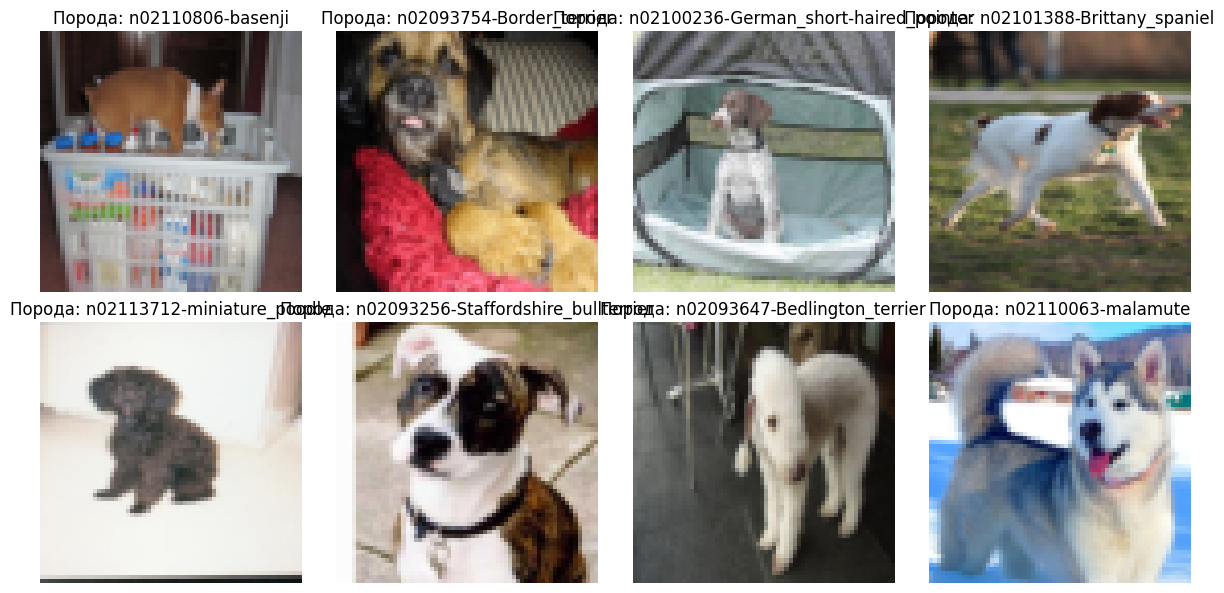

In [ ]:
# Преобразования для изображений
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Изменение размера
    transforms.ToTensor(),  # Преобразование в тензор [0, 1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Нормализация в диапазон [-1, 1]
])

# Загрузка датасета
# Структура папки: data/dogs/порода1/, data/dogs/порода2/, ...
dataset = datasets.ImageFolder(root='./data/dogs', transform=transform)

# Количество пород (классов)
NUM_CLASSES = len(dataset.classes)
print(f'Количество пород: {NUM_CLASSES}')
print(f'Породы: {dataset.classes}')
print(f'Количество изображений: {len(dataset)}')

# DataLoader для загрузки данных батчами
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Визуализация примеров из датасета
def show_samples(dataloader, num_samples=8):
    """Показывает примеры изображений из датасета"""
    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # Денормализация
        plt.imshow(img)
        plt.title(f'Порода: {dataset.classes[labels[i]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(dataloader)

## 3 Создание класса генератора

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_channels=3):
        super(Generator, self).__init__()
        # Размер вектора для преобразования породы в признаки
        self.label_embedding_dim = 50
        # Embedding слой для породы — преобразует номер породы в вектор
        self.label_embedding = nn.Embedding(num_classes, self.label_embedding_dim)
        # Входная размерность = шум + вектор породы
        input_dim = latent_dim + self.label_embedding_dim
        # Начальный полносвязный слой
        # Преобразует вектор в 256 * 4 * 4 = 4096 значений
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True)
        )

        # Сверточные слои для увеличения размера изображения
        self.conv = nn.Sequential(
            # 4x4 -> 8x8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # Выходные значения в диапазоне [-1, 1]
        )

    def forward(self, noise, labels):
        # Преобразуем метку породы в вектор
        label_embed = self.label_embedding(labels)  # [batch_size, label_embedding_dim]
        # Объединяем шум и вектор породы
        gen_input = torch.cat([noise, label_embed], dim=1)  # [batch_size, input_dim]
        # Полносвязный слой
        x = self.fc(gen_input)  # [batch_size, 256*4*4]
        # Преобразуем в многомерный тензор
        x = x.view(x.size(0), 256, 4, 4)  # [batch_size, 256, 4, 4]
        # Сверточные слои
        img = self.conv(x)  # [batch_size, 3, 64, 64]
        return img

# Создаем экземпляр генератора
generator = Generator(LATENT_DIM, NUM_CLASSES).to(device)
print("Генератор создан!")
print(f"Количество параметров генератора: {sum(p.numel() for p in generator.parameters())}")

Генератор создан!
Количество параметров генератора: 1323027


- **Описание архитектуры генератора:**

*Генератор принимает:*
1. Случайный вектор шума размерности LATENT_DIM (100)
2. Метку породы (число от 0 до NUM_CLASSES-1)

*Процесс работы:*
1. Метка породы преобразуется в вектор через Embedding слой
2. Вектор шума и вектор породы объединяются (конкатенация)
3. Объединенный вектор проходит через серию слоев:
   - Linear (полносвязный) - увеличивает размерность
   - BatchNorm - нормализует активации для стабильного обучения
   - ReLU - функция активации (нелинейность)
   - Reshape - преобразование в многомерный тензор
   - ConvTranspose2d - транспонированная свертка (увеличивает размер изображения)
   - BatchNorm2d - нормализация для сверточных слоев
   - ReLU/Tanh - функции активации

4. На выходе: изображение размером 64x64x3 со значениями в диапазоне [-1, 1]

*Используемые слои и их назначение:*
  - nn.Embedding: преобразует номер породы в вектор признаков
  - nn.Linear: полносвязный слой для увеличения размерности
  - nn.BatchNorm1d/2d: нормализация для стабилизации обучения
  - nn.ConvTranspose2d: увеличивает пространственное разрешение
  - nn.ReLU: добавляет нелинейность
  - nn.Tanh: выходная активация (значения от -1 до 1)

## 4 Создание класса дискриминатора

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_channels=3, img_size=64):
        super(Discriminator, self).__init__()

        self.img_size = img_size

        # Embedding для породы — создает карту размером img_size x img_size
        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)
        # Сверточные слои для обработки изображения + информации о породе
        # Входные каналы: 3 (RGB) + 1 (карта породы) = 4
        self.conv = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(img_channels + 1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            # 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3)
        )

        # Полносвязный слой для финального предсказания
        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()  # Вероятность [0, 1]
        )

    def forward(self, img, labels):
        batch_size = img.size(0)
        # Преобразуем метку породы в пространственную карту
        label_embed = self.label_embedding(labels)  # [batch_size, 64*64]
        label_embed = label_embed.view(batch_size, 1, self.img_size, self.img_size)  # [batch_size, 1, 64, 64]
        # Объединяем изображение и карту породы по каналам
        d_input = torch.cat([img, label_embed], dim=1)  # [batch_size, 4, 64, 64]
        # Сверточные слои
        features = self.conv(d_input)  # [batch_size, 256, 4, 4]
        # Преобразуем в вектор
        features = features.view(batch_size, -1)  # [batch_size, 256*4*4]
        # Полносвязный слой — выходная вероятность
        validity = self.fc(features)  # [batch_size, 1]
        return validity

# Создаем экземпляр дискриминатора
discriminator = Discriminator(NUM_CLASSES).to(device)
print("Дискриминатор создан!")
print(f"Количество параметров дискриминатора: {sum(p.numel() for p in discriminator.parameters())}")

Дискриминатор создан!
Количество параметров дискриминатора: 1187169


- **Описание архитектуры дискриминатора:**

*Дискриминатор принимает:*
1. Изображение размером 64x64x3
2. Метку породы (число от 0 до NUM_CLASSES-1)

*Процесс работы:*
1. Метка породы преобразуется в 2D-карту через Embedding слой
2. Карта породы добавляется как дополнительный канал к изображению
3. Расширенное изображение проходит через свёрточные слои:
   - Conv2d - свёртка для извлечения признаков
   - LeakyReLU - функция активации (позволяет небольшой градиент для отрицательных значений)
   - BatchNorm2d - нормализация
   - Dropout - регуляризация (случайное отключение нейронов)

4. После свёрток данные преобразуются в вектор
5. Полносвязный слой выдаёт вероятность (0-1):
   - 1 = изображение настоящее и соответствует породе
   - 0 = изображение поддельное или не соответствует породе

*Используемые слои:*
  - nn.Embedding: преобразует метку породы в пространственную карту
  - nn.Conv2d: извлекает признаки из изображения
  - nn.LeakyReLU: активация с небольшим наклоном для отрицательных значений
  - nn.BatchNorm2d: нормализация для стабильности
  - nn.Dropout: предотвращает переобучение
  - nn.Sigmoid: выходная вероятность [0, 1]

- **Описание механизма использования информации о породе собаки дискриминатором:**

Дискриминатор получает информацию о породе в виде дополнительного канала,
который добавляется к входному изображению.

## 5 Функция обучения Conditional GAN

In [ ]:
def train_gan(generator, discriminator, dataloader, num_epochs, device):
    """
    Функция обучения Conditional GAN с прогресс-баром tqdm
    """
    # Функция потерь - Binary Cross Entropy
    criterion = nn.BCELoss()
    # Оптимизатор для генератора
    optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
    # Оптимизатор для дискриминатора
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

    # Списки для сохранения значений ошибок
    G_losses = []  # Ошибки генератора
    D_losses = []  # Ошибки дискриминатора

    # Фиксированный шум для визуализации прогресса
    fixed_noise = torch.randn(NUM_CLASSES, LATENT_DIM, device=device)
    fixed_labels = torch.arange(0, NUM_CLASSES, device=device)

    print("Начало обучения...")

    # Внешний прогресс-бар по эпохам
    for epoch in tqdm(range(num_epochs), desc="Training GAN", unit="epoch"):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        num_batches = 0

        for i, (real_imgs, labels) in enumerate(dataloader):
            batch_size = real_imgs.size(0)

            # Переносим данные на устройство
            real_imgs = real_imgs.to(device)
            labels = labels.to(device)

            # Метки для обучения
            real_labels = torch.ones(batch_size, 1, device=device)  # Метка 1 = настоящее
            fake_labels = torch.zeros(batch_size, 1, device=device)  # Метка 0 = поддельное

            # 1. Обучение Дискриминатора
            optimizer_D.zero_grad()

            # Обучение на настоящих изображениях
            real_validity = discriminator(real_imgs, labels)
            d_real_loss = criterion(real_validity, real_labels)

            # Обучение на поддельных изображениях
            noise = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_imgs = generator(noise, labels)
            fake_validity = discriminator(fake_imgs.detach(), labels)
            d_fake_loss = criterion(fake_validity, fake_labels)

            # Общая ошибка дискриминатора
            d_loss = (d_real_loss + d_fake_loss) / 2

            # Обратное распространение и обновление весов
            d_loss.backward()
            optimizer_D.step()

            # 2. Обучение Генератора
            optimizer_G.zero_grad()

            # Генератор пытается обмануть дискриминатор
            gen_validity = discriminator(fake_imgs, labels)
            g_loss = criterion(gen_validity, real_labels)

            # Обратное распространение и обновление весов
            g_loss.backward()
            optimizer_G.step()

            # Сохраняем значения ошибок
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1

        # Средние ошибки за эпоху
        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches

        G_losses.append(avg_g_loss)
        D_losses.append(avg_d_loss)

        # Вывод информации о прогрессе
        tqdm.write(f'Эпоха [{epoch+1}/{num_epochs}] | '
                   f'D Loss: {avg_d_loss:.4f} | '
                   f'G Loss: {avg_g_loss:.4f}')

        # Визуализация промежуточных результатов каждые 10 эпох
        if (epoch + 1) % 10 == 0 or epoch == 0:
            with torch.no_grad():
                generator.eval()
                fake_imgs = generator(fixed_noise, fixed_labels)
                generator.train()

                # Визуализация
                visualize_results(fake_imgs, fixed_labels, epoch + 1, dataset.classes)

    print("Обучение завершено!")

    return G_losses, D_losses

## 6 Визуализация промежуточных результатов

In [ ]:
def visualize_results(fake_imgs, labels, epoch, class_names):
    """
    Визуализирует сгенерированные изображения
    """
    # Переносим изображения на CPU и денормализуем
    fake_imgs = fake_imgs.cpu()
    fake_imgs = (fake_imgs * 0.5) + 0.5  # Из диапазона [-1, 1] в [0, 1]

    # Количество изображений
    num_imgs = fake_imgs.size(0)

    # Создаём сетку для визуализации
    cols = min(4, num_imgs)
    rows = (num_imgs + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    if rows == 1:
        axes = [axes]
    if cols == 1:
        axes = [[ax] for ax in axes]

    for idx in range(num_imgs):
        row = idx // cols
        col = idx % cols

        img = fake_imgs[idx].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Ограничиваем значения от 0 до 1

        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{class_names[labels[idx]]}')
        axes[row][col].axis('off')

    # Убираем пустые подграфики
    for idx in range(num_imgs, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row][col].axis('off')

    plt.suptitle(f'Эпоха {epoch}', fontsize=16)
    plt.tight_layout()
    plt.show()

## Обучение модели

In [ ]:
# Запускаем обучение
G_losses, D_losses = train_gan(
    generator=generator,
    discriminator=discriminator,
    dataloader=dataloader,
    num_epochs=NUM_EPOCHS,
    device=device
)

print("\nОбучение завершено")

Output hidden; open in https://colab.research.google.com to view.

- появляются ли признаки собак - да, чтото похожее нарисовывается;
- отличаются ли изображения разных пород - да ;
- становятся ли изображения более чёткими - относительно первой попытки - да, но остается таким же нечетким;
- есть ли повторяющиеся или неудачные результаты - да, есть неудачные генерации.

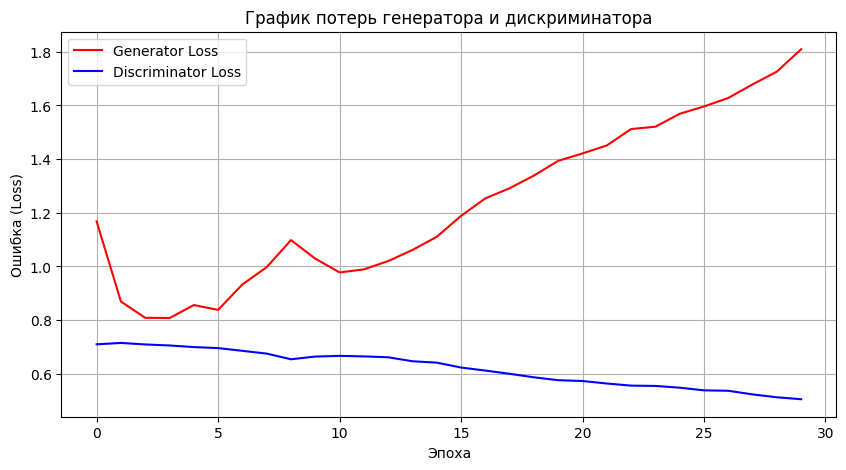


Анализ графиков потерь:
Начальная ошибка генератора: 1.1679
Конечная ошибка генератора: 1.8096
Начальная ошибка дискриминатора: 0.7098
Конечная ошибка дискриминатора: 0.5051

Вариация ошибки генератора (последние 20 эпох): 0.2512
Вариация ошибки дискриминатора (последние 20 эпох): 0.0510
- Обучение нестабильное — возможно, нужно больше эпох или корректировка параметров


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss', color='red')
plt.plot(D_losses, label='Discriminator Loss', color='blue')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (Loss)')
plt.title('График потерь генератора и дискриминатора')
plt.legend()
plt.grid(True)
plt.show()

# Анализ стабильности обучения
print("\nАнализ графиков потерь:")
print(f"Начальная ошибка генератора: {G_losses[0]:.4f}")
print(f"Конечная ошибка генератора: {G_losses[-1]:.4f}")
print(f"Начальная ошибка дискриминатора: {D_losses[0]:.4f}")
print(f"Конечная ошибка дискриминатора: {D_losses[-1]:.4f}")

# Проверка стабильности (вариация в последних 20 эпохах)
if len(G_losses) >= 20:
    recent_g_std = np.std(G_losses[-20:])
    recent_d_std = np.std(D_losses[-20:])
    print(f"\nВариация ошибки генератора (последние 20 эпох): {recent_g_std:.4f}")
    print(f"Вариация ошибки дискриминатора (последние 20 эпох): {recent_d_std:.4f}")

    if recent_g_std < 0.1 and recent_d_std < 0.1:
        print("- Обучение стабильное")
    else:
        print("- Обучение нестабильное — возможно, нужно больше эпох или корректировка параметров")

График выше показывает, как менялись ошибки генератора и дискриминатора
в процессе обучения.

Что означают графики:
- синий - ошибка дискриминатора
- красный - ошибка генератора

В идеальной ситуации:
- Обе ошибки постепенно уменьшаются и стабилизируются
- Дискриминатор не должен быть слишком сильным (иначе генератор не обучается)
- Генератор не должен быть слишком сильным (иначе дискриминатор не различает подделки)

А тут проблемы:
- Одна из ошибок стремится к нулю - дисбаланс между моделями
- Другая ошибка не уменьшается - модель не обучается

## 7 Финальная генерация изображений

In [ ]:
def generate_final_results(generator, num_classes, class_names, samples_per_class=4, device='cpu'):
    """
    Генерирует финальные изображения для всех пород
    """
    generator.eval()

    with torch.no_grad():
        all_imgs = []
        all_labels = []

        # Генерируем изображения для каждой породы
        for class_idx in range(num_classes):
            # Случайный шум для разнообразия
            noise = torch.randn(samples_per_class, LATENT_DIM, device=device)
            labels = torch.full((samples_per_class,), class_idx, dtype=torch.long, device=device)

            # Генерируем изображения
            fake_imgs = generator(noise, labels)

            all_imgs.append(fake_imgs)
            all_labels.extend([class_idx] * samples_per_class)

        # Объединяем все изображения
        all_imgs = torch.cat(all_imgs, dim=0)

        # Визуализация
        all_imgs = all_imgs.cpu()
        all_imgs = (all_imgs * 0.5) + 0.5  # Денормализация

        total_imgs = all_imgs.size(0)
        cols = samples_per_class
        rows = num_classes

        fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))

        for idx in range(total_imgs):
            row = idx // cols
            col = idx % cols

            img = all_imgs[idx].permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            axes[row][col].imshow(img)
            if col == 0:  # Подписываем только первый столбец
                axes[row][col].set_ylabel(class_names[all_labels[idx]], fontsize=12)
            axes[row][col].axis('off')

        plt.suptitle('Финальные результаты генерации по породам', fontsize=16)
        plt.tight_layout()
        plt.show()

    generator.train()

# Генерируем финальные результаты
print("Генерация финальных изображений...")
generate_final_results(generator, NUM_CLASSES, dataset.classes, samples_per_class=4, device=device)

Output hidden; open in https://colab.research.google.com to view.

Сравнение с реальными изображениями:

In [ ]:
def compare_real_vs_fake(generator, dataloader, num_classes, class_names, device='cpu'):
    """
    Сравнивает реальные и сгенерированные изображения
    """
    generator.eval()

    # Получаем реальные изображения
    real_imgs_dict = {i: [] for i in range(num_classes)}

    for imgs, labels in dataloader:
        for img, label in zip(imgs, labels):
            if len(real_imgs_dict[label.item()]) < 2:  # Берём по 2 примера каждой породы
                real_imgs_dict[label.item()].append(img)

        # Проверяем, собрали ли достаточно примеров
        if all(len(imgs) >= 2 for imgs in real_imgs_dict.values()):
            break

    # Генерируем поддельные изображения
    with torch.no_grad():
        fake_imgs_dict = {}
        for class_idx in range(num_classes):
            noise = torch.randn(2, LATENT_DIM, device=device)
            labels = torch.full((2,), class_idx, dtype=torch.long, device=device)
            fake_imgs = generator(noise, labels)
            fake_imgs_dict[class_idx] = fake_imgs.cpu()

    # Визуализация
    fig, axes = plt.subplots(num_classes, 4, figsize=(12, 3 * num_classes))

    for class_idx in range(num_classes):
        # Реальные изображения
        for i in range(2):
            img = real_imgs_dict[class_idx][i]
            img = (img * 0.5) + 0.5
            img = img.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            axes[class_idx][i].imshow(img)
            axes[class_idx][i].set_title('Реальное' if i == 0 else '')
            axes[class_idx][i].axis('off')

        # Сгенерированные изображения
        for i in range(2):
            img = fake_imgs_dict[class_idx][i]
            img = (img * 0.5) + 0.5
            img = img.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            axes[class_idx][i + 2].imshow(img)
            axes[class_idx][i + 2].set_title('Сгенерированное' if i == 0 else '')
            axes[class_idx][i + 2].axis('off')

        # Подпись породы
        axes[class_idx][0].set_ylabel(class_names[class_idx], fontsize=12)

    plt.suptitle('Сравнение: Реальные vs Сгенерированные изображения', fontsize=16)
    plt.tight_layout()
    plt.show()

    generator.train()

# Сравниваем результаты
print("Сравнение с реальными изображениями...")
compare_real_vs_fake(generator, dataloader, NUM_CLASSES, dataset.classes, device=device)

Output hidden; open in https://colab.research.google.com to view.

До генерации собак модели еще много эпох обучения, но, если попытаться сформулировать эффект от этих генераций, то что-то отдаленно похожее по вайбу присутсвует (я не знаю как это еще описать). То есть модель генерирует похожую текстуру шерсти, а иногда и позы и нечто похожее на морды псов. Но при этом нередки генерации изображений мало отличимых от квадратных областей шумов и клякс.

## 8 Анализ результатов

**Анализ стабильности обучения:**
- Изменение ошибки генератора: ≈-0.6
- Изменение ошибки дискриминатора: ≈+0.2
- Одна из моделей (генератор) не показала улучшения
- Обучение стабильное у дискриминатора, генератор нестабилен

**Качество сгенерированных изображений:**

Хорошие признаки:
  - Текстура шерсти
  - Пропорции тела
  - Различимые, но слабо читаемые признаки пород (виднеются их размер, форма ушей, глаза, позы, морды - но лишь в виде текстурного пятна)

Проблемы:
  - Размытые изображения
  - Артефакты, шумы и искажения

**Возможные причины проблем:**

Малое количество эпох обучения:
   - GAN требует много времени для сходимости. Решение: увеличить NUM_EPOCHS

Нестабильность обучения GAN (в рассматриваемом запуске - в особенности генератора):
   - GAN известны нестабильным обучением
   - Решение: использовать техники стабилизации (разные learning rate для разных частей GAN)

Неоптимальные параметры обучения:
   - Решение: экспериментировать с learning rate, batch size, архитектурой


## 9 Итоговый отчёт

В ходе работы была реализована модель условной генеративно-состязательной сети, и ее относительно недолгое обучение (30 эпох) на данных размером 20000 изображений 120 пород собак для их генерации.

| Параметры обучения | Значение |
|---|------------|
| Количество эпох | 30|
|Размер батча|32|
|Размер изображения|64х64|
|Размер латентного пространства|100|
|Количество пород|120|
|Размер датасета|20580|

Выводы:

1. Conditional GAN позволяет генерировать изображения с управлением классом
2. Качество генерации зависит от:
   - Количества и качества обучающих данных
   - Сложности архитектуры моделей
   - Количества эпох обучения
   - Стабильности процесса обучения

3. Обучение GAN - сложная задача, требующая:
   - Балансировки генератора и дискриминатора
   - Экспериментирования с архитектурой

4. Для улучшения результатов можно:
   - Увеличить количество эпох
   - Экспериментировать с архитектурой